In [ ]:
import pandas as pd

df = pd.read_csv("/content/tmdb-movies.csv")

print(df.head())
print(df.info())
print(df.columns)
print(df.shape)

       id    imdb_id  popularity     budget     revenue  \
0  135397  tt0369610   32.985763  150000000  1513528810   
1   76341  tt1392190   28.419936  150000000   378436354   
2  262500  tt2908446   13.112507  110000000   295238201   
3  140607  tt2488496   11.173104  200000000  2068178225   
4  168259  tt2820852    9.335014  190000000  1506249360   

                 original_title  runtime  \
0                Jurassic World      124   
1            Mad Max: Fury Road      120   
2                     Insurgent      119   
3  Star Wars: The Force Awakens      136   
4                     Furious 7      137   

                                      genres release_date  vote_count  \
0  Action|Adventure|Science Fiction|Thriller       6/9/15        5562   
1  Action|Adventure|Science Fiction|Thriller      5/13/15        6185   
2         Adventure|Science Fiction|Thriller      3/18/15        2480   
3   Action|Adventure|Science Fiction|Fantasy     12/15/15        5292   
4              

In [ ]:
import pandas as pd

# =========================
# DISPLAY SETTINGS (IMPORTANT)
# =========================
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', 1000)         # avoid line breaks
pd.set_option('display.max_colwidth', None)  # show full column content

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("/content/tmdb-movies.csv")

# =========================
# SHOW DATA IN TABLE FORMAT
# =========================
print("\n===== FIRST 5 ROWS =====\n")
display(df.head())

print("\n===== DATA INFO =====\n")
df.info()

print("\n===== COLUMN NAMES =====\n")
print(df.columns)

print("\n===== DATA SHAPE =====\n")
print(df.shape)


===== FIRST 5 ROWS =====



,id,imdb_id,popularity,budget,revenue,original_title,runtime,genres,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,124,Action|Adventure|Science Fiction|Thriller,6/9/15,5562,6.5,2015,137999939.3,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,120,Action|Adventure|Science Fiction|Thriller,5/13/15,6185,7.1,2015,137999939.3,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,119,Adventure|Science Fiction|Thriller,3/18/15,2480,6.3,2015,101199955.5,2.716190e+08
3,140607,tt2488496,11.173104,200000000,2068178225,Star Wars: The Force Awakens,136,Action|Adventure|Science Fiction|Fantasy,12/15/15,5292,7.5,2015,183999919.0,1.902723e+09
4,168259,tt2820852,9.335014,190000000,1506249360,Furious 7,137,Action|Crime|Thriller,4/1/15,2947,7.3,2015,174799923.1,1.385749e+09



===== DATA INFO =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10866 non-null  int64  
 1   imdb_id         10856 non-null  object 
 2   popularity      10866 non-null  float64
 3   budget          10866 non-null  int64  
 4   revenue         10866 non-null  int64  
 5   original_title  10866 non-null  object 
 6   runtime         10866 non-null  int64  
 7   genres          10843 non-null  object 
 8   release_date    10866 non-null  object 
 9   vote_count      10866 non-null  int64  
 10  vote_average    10866 non-null  float64
 11  release_year    10866 non-null  int64  
 12  budget_adj      10866 non-null  float64
 13  revenue_adj     10866 non-null  float64
dtypes: float64(4), int64(6), object(4)
memory usage: 1.2+ MB

===== COLUMN NAMES =====

Index(['id', 'imdb_id', 'popularity', 'budget', 'revenue',

In [ ]:
# =========================
# FEATURE ENGINEERING (FINAL VERSION)
# =========================

import pandas as pd
import numpy as np

# =========================
# 1. LOAD DATASET
# =========================
df = pd.read_csv("/content/tmdb-movies.csv")

# =========================
# 2. SELECT REQUIRED COLUMNS
# =========================
df = df[['budget', 'revenue', 'runtime', 'genres',
         'popularity', 'release_date', 'vote_average', 'vote_count']]

# =========================
# 3. REMOVE MISSING VALUES
# =========================
df = df.dropna()

# =========================
# 4. REMOVE INVALID VALUES
# =========================
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
df = df[df['runtime'] > 0]

# =========================
# 5. FIX RELEASE DATE (NO WARNING)
# =========================

# First attempt: standard format
df['release_date'] = pd.to_datetime(
    df['release_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

# Second attempt: handle mixed formats
mask = df['release_date'].isna()

df.loc[mask, 'release_date'] = pd.to_datetime(
    df.loc[mask, 'release_date'],
    format='mixed',
    errors='coerce'
)

# Remove rows where conversion still failed
df = df.dropna(subset=['release_date'])

# =========================
# 6. CREATE RELEASE MONTH
# =========================
df['release_month'] = df['release_date'].dt.month

# =========================
# 7. CREATE RELEASE SEASON
# =========================
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df['release_season'] = df['release_month'].apply(get_season)

# =========================
# 8. EXTRACT MAIN GENRE
# =========================
df['main_genre'] = df['genres'].apply(lambda x: str(x).split('|')[0])

# =========================
# 9. DROP UNUSED COLUMNS
# =========================
df = df.drop(['genres', 'release_date'], axis=1)

# =========================
# 10. FINAL CHECK
# =========================
print("✅ Cleaned dataset shape:", df.shape)
print("✅ Missing release_month values:", df['release_month'].isna().sum())
print("\nSample Data:\n")
print(df.head())

✅ Cleaned dataset shape: (0, 9)
✅ Missing release_month values: 0

Sample Data:

Empty DataFrame
Columns: [budget, revenue, runtime, popularity, vote_average, vote_count, release_month, release_season, main_genre]
Index: []


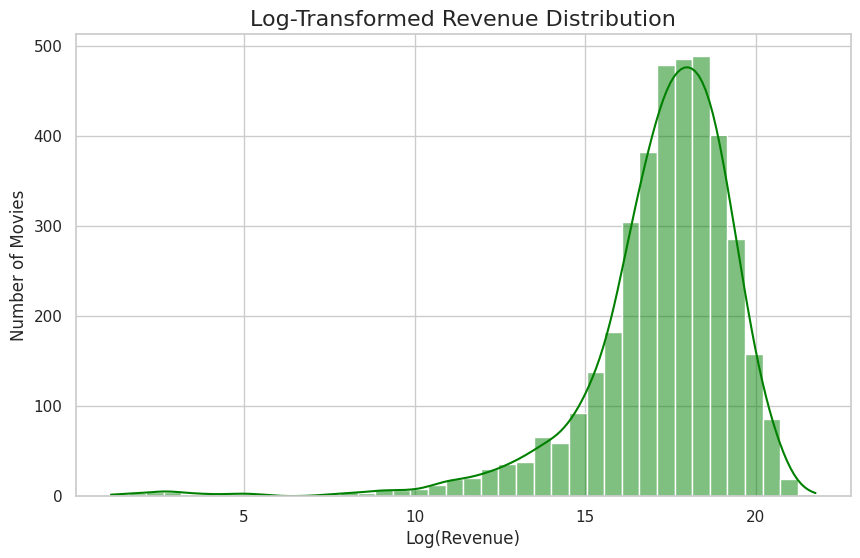

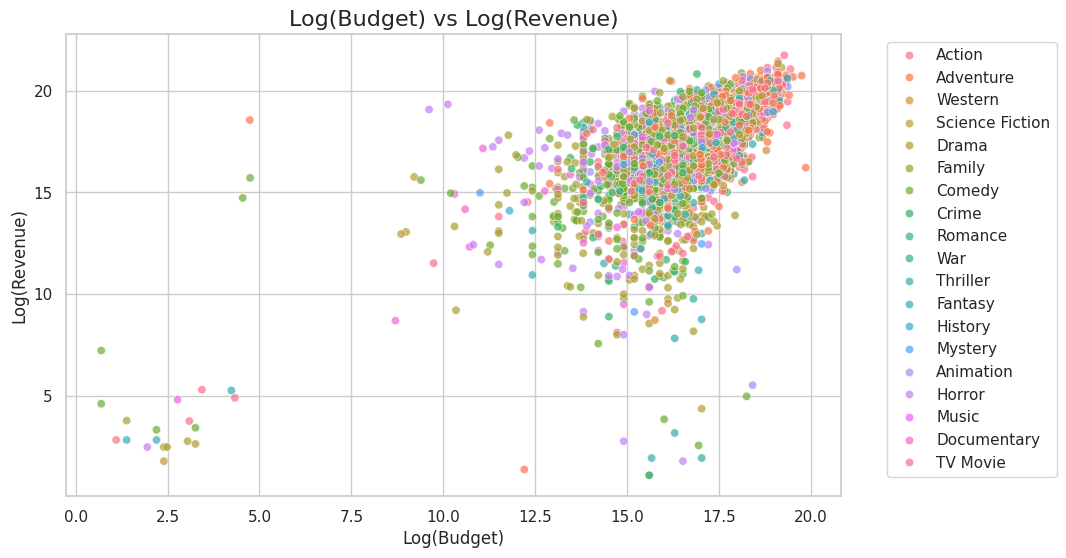

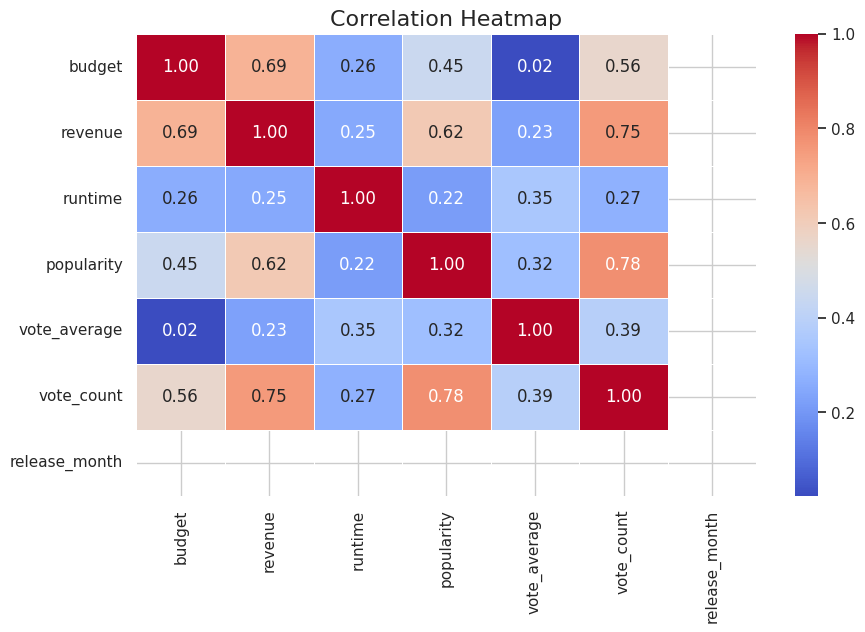

/tmp/ipykernel_11934/815956427.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


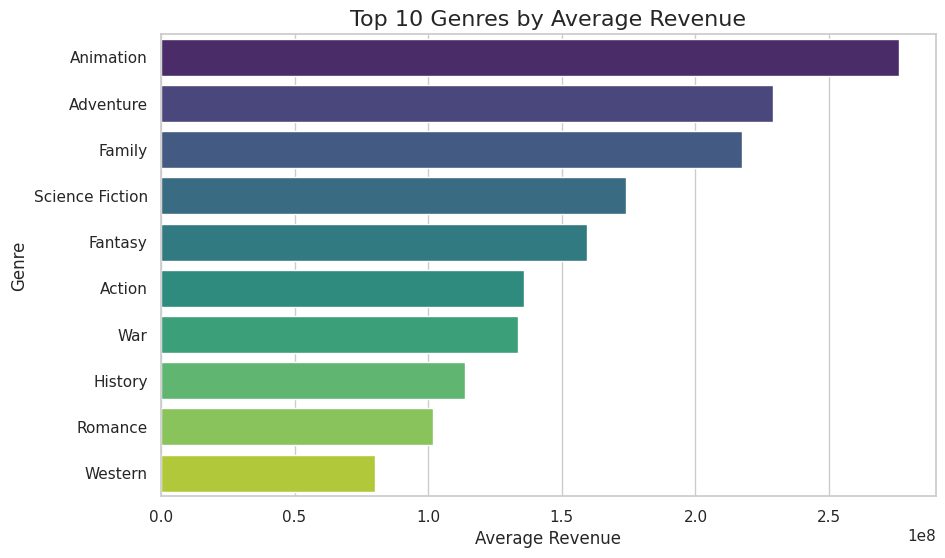

EDA completed successfully.
All plots are saved inside the 'plots' folder.


In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


# =========================
# 2. CREATE PLOTS FOLDER
# =========================
os.makedirs("plots", exist_ok=True)


# =========================
# 3. LOAD DATASET
# =========================
df = pd.read_csv("/content/tmdb-movies.csv")


# =========================
# 4. SELECT REQUIRED COLUMNS
# =========================
df = df[['budget', 'revenue', 'runtime', 'genres',
         'popularity', 'release_date', 'vote_average', 'vote_count']]


# =========================
# 5. CLEAN DATA
# =========================
df = df.dropna()

df = df[(df['budget'] > 0) & (df['revenue'] > 0)]
df = df[df['runtime'] > 0]


# =========================
# 6. FEATURE ENGINEERING
# =========================
df['release_date'] = pd.to_datetime(
    df['release_date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df['release_month'] = df['release_date'].dt.month
df['main_genre'] = df['genres'].apply(lambda x: str(x).split('|')[0])

df = df.drop(['genres', 'release_date'], axis=1)


# =========================
# 7. STYLE SETTINGS
# =========================
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


# =========================
# 8. PLOT 1: LOG REVENUE DISTRIBUTION
# =========================
plt.figure()
sns.histplot(np.log1p(df['revenue']), bins=40, kde=True, color='green')
plt.title("Log-Transformed Revenue Distribution", fontsize=16)
plt.xlabel("Log(Revenue)")
plt.ylabel("Number of Movies")
plt.savefig("plots/log_revenue_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


# =========================
# 9. PLOT 2: LOG BUDGET VS LOG REVENUE
# =========================
plt.figure()
sns.scatterplot(
    x=np.log1p(df['budget']),
    y=np.log1p(df['revenue']),
    hue=df['main_genre'],
    alpha=0.7
)

plt.title("Log(Budget) vs Log(Revenue)", fontsize=16)
plt.xlabel("Log(Budget)")
plt.ylabel("Log(Revenue)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("plots/log_budget_vs_log_revenue.png", dpi=300, bbox_inches='tight')
plt.show()


# =========================
# 10. PLOT 3: CORRELATION HEATMAP
# =========================
plt.figure()
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


# =========================
# 11. PLOT 4: TOP GENRES BY AVERAGE REVENUE
# =========================
plt.figure()

genre_revenue = (
    df.groupby('main_genre')['revenue']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=genre_revenue.values,
    y=genre_revenue.index,
    palette='viridis'
)

plt.title("Top 10 Genres by Average Revenue", fontsize=16)
plt.xlabel("Average Revenue")
plt.ylabel("Genre")
plt.savefig("plots/top_genres_average_revenue.png", dpi=300, bbox_inches='tight')
plt.show()


# =========================
# 12. FINAL CHECK
# =========================
print("EDA completed successfully.")
print("All plots are saved inside the 'plots' folder.")

In [ ]:
# =========================
# STEP 4: MACHINE LEARNING (FIXED)
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =========================
# 1. REMOVE PROBLEM COLUMN
# =========================
if 'release_month' in df.columns:
    df = df.drop('release_month', axis=1)


# =========================
# 2. FEATURES AND TARGET
# =========================
X = df.drop('revenue', axis=1)
y = np.log1p(df['revenue'])


# =========================
# 3. FEATURE TYPES
# =========================
numeric_features = [
    'budget',
    'runtime',
    'popularity',
    'vote_average',
    'vote_count'
]

categorical_features = ['main_genre']


# =========================
# 4. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# =========================
# 6. MODELS
# =========================
models = {
    "MLP Neural Network": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Linear Regression": LinearRegression()
}


# =========================
# 7. TRAIN + EVALUATE
# =========================
results = []

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])


# =========================
# 8. RESULTS
# =========================
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2 Score'])
print(results_df)

                Model       MAE      RMSE  R2 Score
0  MLP Neural Network  1.099906  1.776084  0.408005
1       Random Forest  0.999125  1.542535  0.553459
2   Linear Regression  1.246195  1.917247  0.310162


In [ ]:
# =========================
# 10. MODEL COMPARISON TABLE
# =========================

# The results_df already contains the comparison table
# No need to recreate comparison_df from 'results' list

print("\nMODEL COMPARISON:")
print(results_df)



MODEL COMPARISON:
               Model       MAE      RMSE        R2
2  Gradient Boosting  1.002189  1.537074  0.556616
1      Random Forest  0.996381  1.537185  0.556552
0        Complex MLP  1.078634  1.702094  0.456302
3  Linear Regression  1.246195  1.917247  0.310162


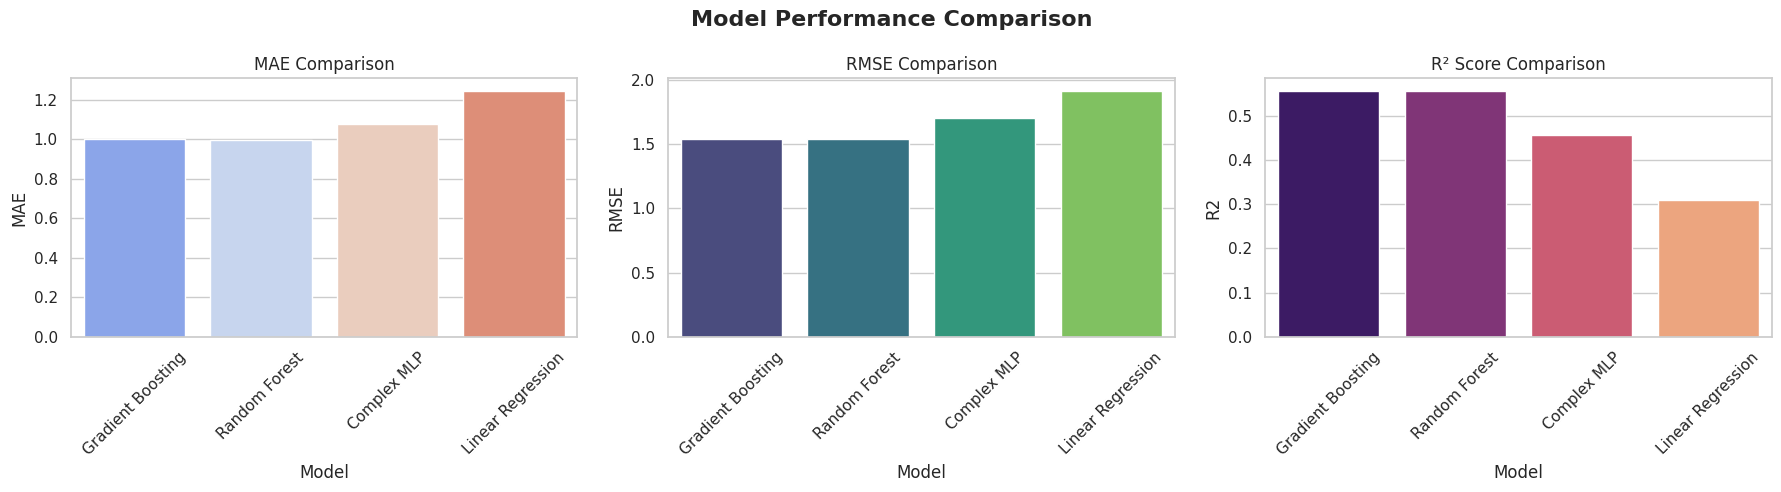

In [ ]:
# 11. MODEL COMPARISON VISUALIZATION (COLORFUL)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Performance Comparison", fontsize=16, fontweight="bold")

# MAE
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="coolwarm", hue="Model", legend=False)
axes[0].set_title("MAE Comparison")

# RMSE
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="viridis", hue="Model", legend=False)
axes[1].set_title("RMSE Comparison")

# R2
sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="magma", hue="Model", legend=False)
axes[2].set_title("R² Score Comparison")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("model_plots/model_comparison.png", dpi=300)
plt.show()

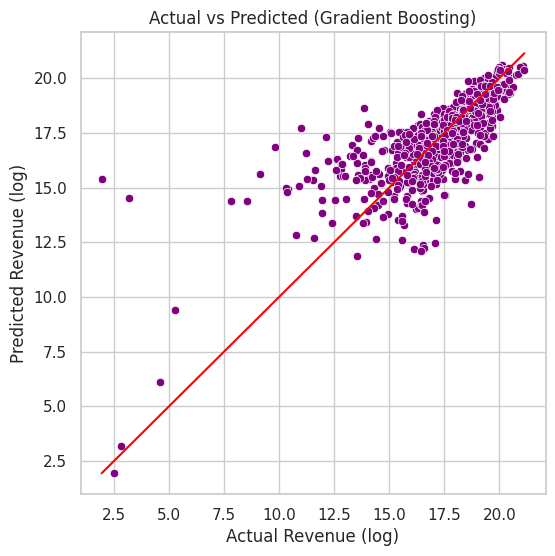

In [ ]:
# 12. ACTUAL vs PREDICTED (BEST MODEL)
# The best_model and best_pred are already computed in the previous step
# Use the best_model and best_pred variables directly

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=best_pred, color="purple")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title(f"Actual vs Predicted ({best_model})")
plt.xlabel("Actual Revenue (log)")
plt.ylabel("Predicted Revenue (log)")

plt.savefig("model_plots/actual_vs_predicted.png", dpi=300)
plt.show()

In [ ]:
# Feature importance only for tree models
if 'rf' in results:
    rf_model = results['rf']['model']

    importances = rf_model.feature_importances_

    feature_names = X.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette="crest")

    plt.title("Feature Importance (Random Forest)")
    plt.savefig("model_plots/feature_importance.png", dpi=300)
    plt.show()

    print("\nFeature Importance:")
    print(importance_df)

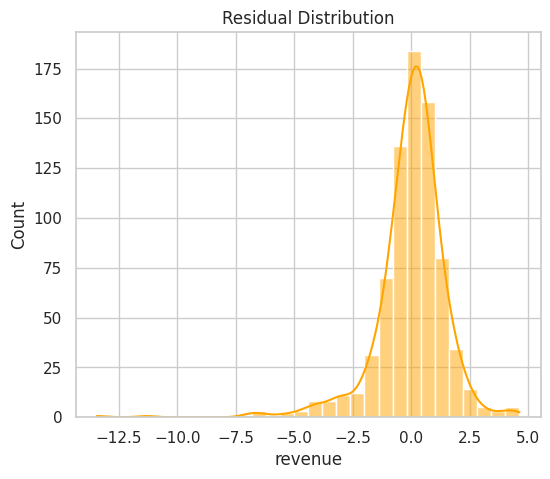

In [ ]:
# =========================
# RESIDUAL PLOT
# =========================
residuals = y_test - best_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, bins=30, kde=True, color="orange")

plt.title("Residual Distribution")
plt.savefig("model_plots/residuals.png", dpi=300)
plt.show()


In [ ]:
# 14. FINAL INTERPRETATION (SHORT LIKE PDF)
print("\n" + "="*60)
print("MODEL INTERPRETATION")
print("="*60)

# Using the already determined best_model_row from previous cells
print(f"\nBest Model: {best_model_row['Model']}")
print(f"R2 Score: {best_model_row['R2']:.4f}")
print(f"MAE: {best_model_row['MAE']:.4f}")
print(f"RMSE: {best_model_row['RMSE']:.4f}")

print("\nInsights:")
print("- Budget and popularity strongly influence revenue.")
print("- Non-linear models perform better than linear models.")
print("- Machine learning can capture hidden patterns in movie success.")


MODEL INTERPRETATION

Best Model: Gradient Boosting
R2 Score: 0.5566
MAE: 1.0022
RMSE: 1.5371

Insights:
- Budget and popularity strongly influence revenue.
- Non-linear models perform better than linear models.
- Machine learning can capture hidden patterns in movie success.


/tmp/ipykernel_11934/2080133143.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="coolwarm")
/tmp/ipykernel_11934/2080133143.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="viridis")
/tmp/ipykernel_11934/2080133143.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="magma")


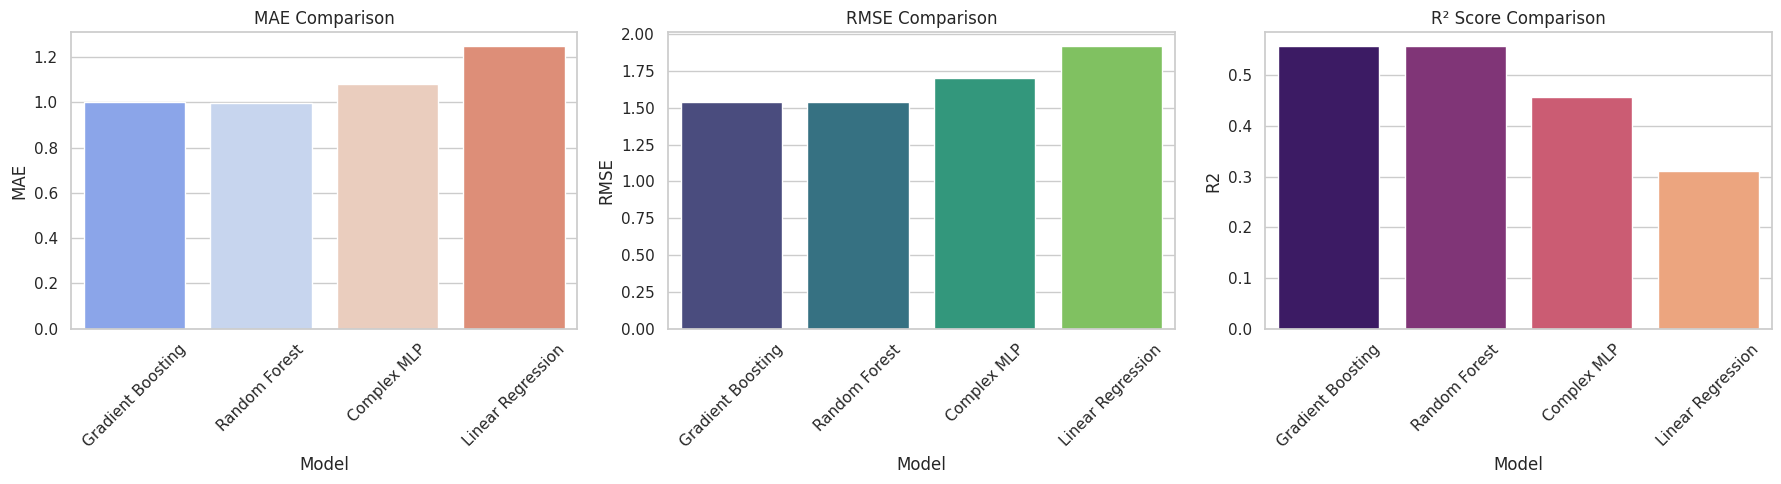

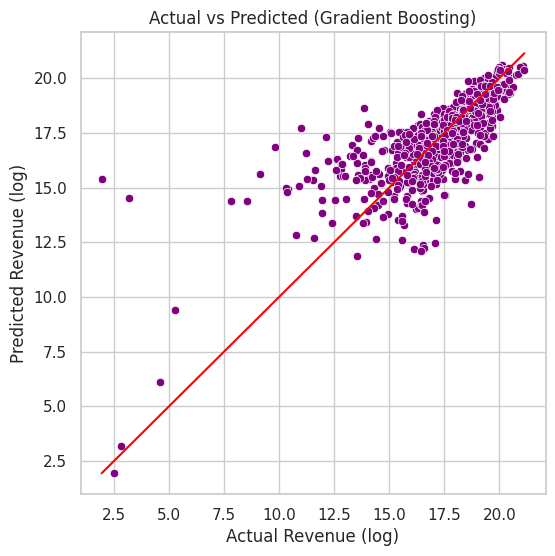

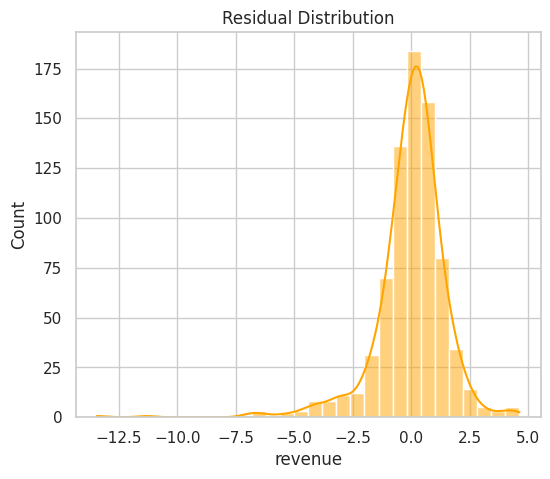

In [ ]:
# =========================
# MODEL COMPARISON GRAPH
# =========================
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="coolwarm")
axes[0].set_title("MAE Comparison")

# RMSE
sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="viridis")
axes[1].set_title("RMSE Comparison")

# R2
sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="magma")
axes[2].set_title("R² Score Comparison")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("model_plots/model_comparison.png", dpi=300)
plt.show()


In [ ]:
# =========================
# ACTUAL VS PREDICTED (BEST MODEL)
# =========================
best_model = results_df.iloc[0]["Model"]
best_pred = predictions[best_model]

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=best_pred, color="purple")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.title(f"Actual vs Predicted ({best_model})")
plt.xlabel("Actual Revenue (log)")
plt.ylabel("Predicted Revenue (log)")

plt.savefig("model_plots/actual_vs_predicted.png", dpi=300)
plt.show()


In [ ]:

# =========================
# RESIDUAL PLOT
# =========================
residuals = y_test - best_pred

plt.figure(figsize=(6,5))
sns.histplot(residuals, bins=30, kde=True, color="orange")

plt.title("Residual Distribution")
plt.savefig("model_plots/residuals.png", dpi=300)
plt.show()